In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

# Create binary classification dataset
X, y = make_moons(n_samples=1000, noise=0.2)
y = y.reshape(-1, 1)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [2]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(z):
    s = sigmoid(z)
    return s * (1 - s)

def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

def tanh(z):
    return np.tanh(z)

def tanh_derivative(z):
    return 1 - np.tanh(z)**2

In [3]:
class NeuralNetwork:
    def __init__(self, input_size, hidden_size, activation='relu', lr=0.01, reg_type=None, lambda_=0.01):
        self.lr = lr
        self.reg_type = reg_type
        self.lambda_ = lambda_

        # Weights initialization
        self.W1 = np.random.randn(input_size, hidden_size) * 0.01
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, 1) * 0.01
        self.b2 = np.zeros((1, 1))

        # Activation selection
        if activation == 'sigmoid':
            self.activation = sigmoid
            self.activation_derivative = sigmoid_derivative
        elif activation == 'tanh':
            self.activation = tanh
            self.activation_derivative = tanh_derivative
        else:
            self.activation = relu
            self.activation_derivative = relu_derivative

    def forward(self, X):
        self.Z1 = np.dot(X, self.W1) + self.b1
        self.A1 = self.activation(self.Z1)
        self.Z2 = np.dot(self.A1, self.W2) + self.b2
        self.A2 = sigmoid(self.Z2)  # output layer (binary)
        return self.A2

    def compute_loss(self, y, y_hat):
        m = y.shape[0]
        loss = -np.mean(y*np.log(y_hat+1e-8) + (1-y)*np.log(1-y_hat+1e-8))

        # Regularization
        if self.reg_type == 'L2':
            loss += (self.lambda_/(2*m)) * (np.sum(self.W1**2) + np.sum(self.W2**2))
        elif self.reg_type == 'L1':
            loss += (self.lambda_/m) * (np.sum(np.abs(self.W1)) + np.sum(np.abs(self.W2)))

        return loss

    def backward(self, X, y):
        m = X.shape[0]

        dZ2 = self.A2 - y
        dW2 = np.dot(self.A1.T, dZ2) / m
        db2 = np.sum(dZ2, axis=0, keepdims=True) / m

        dA1 = np.dot(dZ2, self.W2.T)
        dZ1 = dA1 * self.activation_derivative(self.Z1)
        dW1 = np.dot(X.T, dZ1) / m
        db1 = np.sum(dZ1, axis=0, keepdims=True) / m

        # Regularization gradients
        if self.reg_type == 'L2':
            dW2 += (self.lambda_/m) * self.W2
            dW1 += (self.lambda_/m) * self.W1
        elif self.reg_type == 'L1':
            dW2 += (self.lambda_/m) * np.sign(self.W2)
            dW1 += (self.lambda_/m) * np.sign(self.W1)

        # Update weights
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2

    def train(self, X, y, epochs=1000, batch_size=32):
        losses = []
        for epoch in range(epochs):
            for i in range(0, X.shape[0], batch_size):
                X_batch = X[i:i+batch_size]
                y_batch = y[i:i+batch_size]

                y_hat = self.forward(X_batch)
                self.backward(X_batch, y_batch)

            loss = self.compute_loss(y, self.forward(X))
            losses.append(loss)

            if epoch % 100 == 0:
                print(f"Epoch {epoch}, Loss: {loss:.4f}")

        return losses

    def predict(self, X):
        return (self.forward(X) > 0.5).astype(int)

In [4]:
activations = ['sigmoid', 'relu', 'tanh']
results = {}

for act in activations:
    print(f"\nTraining with {act} activation")
    model = NeuralNetwork(input_size=2, hidden_size=10, activation=act, lr=0.05)
    losses = model.train(X_train, y_train, epochs=500)
    results[act] = losses


Training with sigmoid activation
Epoch 0, Loss: 0.6931
Epoch 100, Loss: 0.3104
Epoch 200, Loss: 0.2958
Epoch 300, Loss: 0.2956
Epoch 400, Loss: 0.2955

Training with relu activation
Epoch 0, Loss: 0.6930
Epoch 100, Loss: 0.2941
Epoch 200, Loss: 0.2933
Epoch 300, Loss: 0.2838
Epoch 400, Loss: 0.2686

Training with tanh activation
Epoch 0, Loss: 0.6928
Epoch 100, Loss: 0.2957
Epoch 200, Loss: 0.2954
Epoch 300, Loss: 0.2952
Epoch 400, Loss: 0.2951


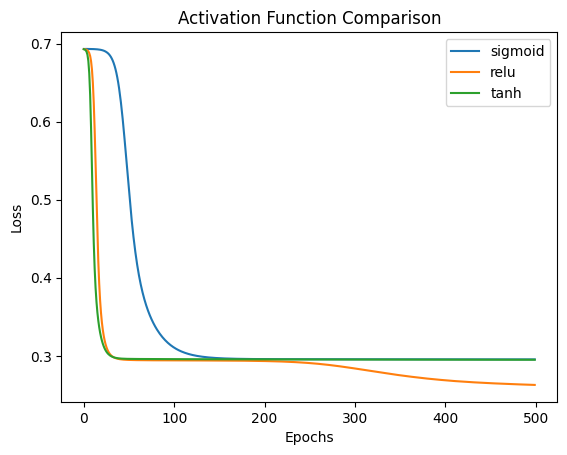

In [5]:
for act in activations:
    plt.plot(results[act], label=act)

plt.legend()
plt.title("Activation Function Comparison")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

In [6]:
learning_rates = [0.001, 0.01, 0.1]

for lr in learning_rates:
    print(f"\nLearning Rate: {lr}")
    model = NeuralNetwork(2, 10, activation='relu', lr=lr)
    model.train(X_train, y_train, epochs=300)


Learning Rate: 0.001
Epoch 0, Loss: 0.6931
Epoch 100, Loss: 0.6930
Epoch 200, Loss: 0.6928

Learning Rate: 0.01
Epoch 0, Loss: 0.6931
Epoch 100, Loss: 0.3895
Epoch 200, Loss: 0.2966

Learning Rate: 0.1
Epoch 0, Loss: 0.6931
Epoch 100, Loss: 0.2903
Epoch 200, Loss: 0.2607


In [7]:
print("\nL2 Regularization")
model_l2 = NeuralNetwork(2, 10, activation='relu', lr=0.01, reg_type='L2')
model_l2.train(X_train, y_train, epochs=300)

print("\nL1 Regularization")
model_l1 = NeuralNetwork(2, 10, activation='relu', lr=0.01, reg_type='L1')
model_l1.train(X_train, y_train, epochs=300)


L2 Regularization
Epoch 0, Loss: 0.6932
Epoch 100, Loss: 0.3830
Epoch 200, Loss: 0.2966

L1 Regularization
Epoch 0, Loss: 0.6931
Epoch 100, Loss: 0.3800
Epoch 200, Loss: 0.2967


[np.float64(0.6930962147270469),
 np.float64(0.6930743088133271),
 np.float64(0.6930526545625759),
 np.float64(0.6930305994439819),
 np.float64(0.6930078226981935),
 np.float64(0.6929839677288896),
 np.float64(0.6929587650736291),
 np.float64(0.6929318678123716),
 np.float64(0.692902906079513),
 np.float64(0.692871476080378),
 np.float64(0.6928371976664315),
 np.float64(0.6927996809922482),
 np.float64(0.6927584627748021),
 np.float64(0.6927129139160393),
 np.float64(0.6926623897298407),
 np.float64(0.6926063193367253),
 np.float64(0.6925440581935265),
 np.float64(0.692474691874185),
 np.float64(0.6923973214271107),
 np.float64(0.6923108996495344),
 np.float64(0.6922141873552023),
 np.float64(0.6921060616735045),
 np.float64(0.6919851067776525),
 np.float64(0.6918497749432769),
 np.float64(0.6916982958161315),
 np.float64(0.6915288333794739),
 np.float64(0.6913392331953218),
 np.float64(0.6911269737985314),
 np.float64(0.690889416585972),
 np.float64(0.690623543888788),
 np.float64(0.6

In [8]:
model = NeuralNetwork(2, 10, activation='relu')
model.train(X_train, y_train, epochs=500)

preds = model.predict(X_test)
accuracy = np.mean(preds == y_test)

print("Test Accuracy:", accuracy)

Epoch 0, Loss: 0.6931
Epoch 100, Loss: 0.4117
Epoch 200, Loss: 0.2989
Epoch 300, Loss: 0.2952
Epoch 400, Loss: 0.2944
Test Accuracy: 0.9
